# Ethiopia Food Prices — 11 MODEL COMPARISON (cereals & tubers)

Pulls together every forecasting and classification approach built so far, reusing the saved score tables
and test-set predictions from `06`–`10` rather than retraining anything, and settles on which model each
downstream notebook (`12 EXPLAINABILITY`, `13 FINAL MODELS`) should carry forward.

**Scope note**: `09`/`10` here are the **cereals & tubers** versions — restricted to Maize, Teff, Wheat,
Sorghum, Rice, Barley, potatoes, and related items, which removed the livestock price-scale problem found
in the original full-panel run (still documented in `09`'s own notebook for reference).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)


## 11.1 Two different forecasting *scopes* — a necessary caveat before comparing anything

`06 BASELINES` and `07 ARIMA/SARIMA` forecast **one national series** (Maize (white), retail, aggregated
across all markets). `09 MACHINE LEARNING FORECASTING` forecasts **every individual market × commodity
series at once**, a much harder, higher-variance task with far more series, many of them thin or volatile.
Their error numbers are **not directly comparable** — lower error on the single smoothed national series is
expected regardless of method. Both are shown below side by side for context, but the actual model
selection in §11.2–§11.5 only ranks models *within* the same scope.


In [2]:
single_series_scores = pd.DataFrame([
    {'Scope': 'Single national series', 'Model': 'Drift (baseline)',            'RMSE': 5.06},
    {'Scope': 'Single national series', 'Model': 'Moving avg k=12 (baseline)',  'RMSE': 5.28},
    {'Scope': 'Single national series', 'Model': 'Naive (baseline)',            'RMSE': 5.32},
    {'Scope': 'Single national series', 'Model': 'Moving avg k=3 (baseline)',   'RMSE': 5.60},
    {'Scope': 'Single national series', 'Model': 'ARIMA(3,1,0)',                'RMSE': 5.14},
    {'Scope': 'Single national series', 'Model': 'SARIMA(1,1,1)x(0,1,1,12)',    'RMSE': 6.48},
    {'Scope': 'Single national series', 'Model': 'Seasonal naive (baseline)',   'RMSE': 7.18},
])

panel_scores = pd.read_csv('../data/09_regression_model_scores_cereals.csv')
panel_scores.insert(0, 'Scope', 'Cereals & tubers panel (829 series)')

pd.concat([single_series_scores, panel_scores[['Scope', 'Model', 'RMSE']]], ignore_index=True).sort_values(['Scope', 'RMSE'])


,Scope,Model,RMSE
7,Cereals & tubers panel (829 series),Persistence (naive),6.421165
8,Cereals & tubers panel (829 series),Hist Gradient Boosting,10.991809
9,Cereals & tubers panel (829 series),Ridge (linear),12.235940
10,Cereals & tubers panel (829 series),Random Forest,13.879691
0,Single national series,Drift (baseline),5.060000
4,Single national series,"ARIMA(3,1,0)",5.140000
1,Single national series,Moving avg k=12 (baseline),5.280000
2,Single national series,Naive (baseline),5.320000
3,Single national series,Moving avg k=3 (baseline),5.600000
5,Single national series,"SARIMA(1,1,1)x(0,1,1,12)",6.480000


Within its own scope, **each group has a different winner**: Drift for the single national series, and
Persistence for the cereals & tubers panel. The common thread — a simple, trend/level-following method
beating more complex models — is itself a genuine finding of this project, not a coincidence, and is
discussed further in §11.5.


## 11.2 Regression models (panel scope) — is the winner's edge real or noise?

In [3]:
panel_scores_sorted = panel_scores.sort_values('RMSE').reset_index(drop=True)
panel_scores_sorted


,Scope,Model,MAE,RMSE,MAPE (%)
0,Cereals & tubers panel (829 series),Persistence (naive),3.046267,6.421165,7.747676
1,Cereals & tubers panel (829 series),Hist Gradient Boosting,5.369400,10.991809,54.606930
2,Cereals & tubers panel (829 series),Ridge (linear),8.244697,12.235940,89.690127
3,Cereals & tubers panel (829 series),Random Forest,7.659285,13.879691,46.810568


In [4]:
preds = pd.read_csv('../data/09_regression_test_predictions_cereals.csv')
target = preds['target_next_usdprice']

errors = pd.DataFrame({
    'Persistence': (target - preds['pred_persistence']).abs(),
    'Ridge': (target - preds['pred_ridge']).abs(),
    'Random Forest': (target - preds['pred_random_forest']).abs(),
    'Hist Gradient Boosting': (target - preds['pred_hist_gb']).abs(),
})

rng = np.random.default_rng(42)
n_boot = 2000
n = len(errors)
diffs = np.empty(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, n, n)
    diffs[i] = errors['Hist Gradient Boosting'].values[idx].mean() - errors['Persistence'].values[idx].mean()

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f'Bootstrap 95% CI for (best ML MAE - Persistence MAE): [{ci_low:.2f}, {ci_high:.2f}] USD')
print('Entirely positive interval -> Persistence beats the best ML model with high confidence (not just noise).'
      if ci_low > 0 else 'Interval crosses zero -> the gap is not statistically clear-cut.')


Bootstrap 95% CI for (best ML MAE - Persistence MAE): [1.96, 2.71] USD
Entirely positive interval -> Persistence beats the best ML model with high confidence (not just noise).


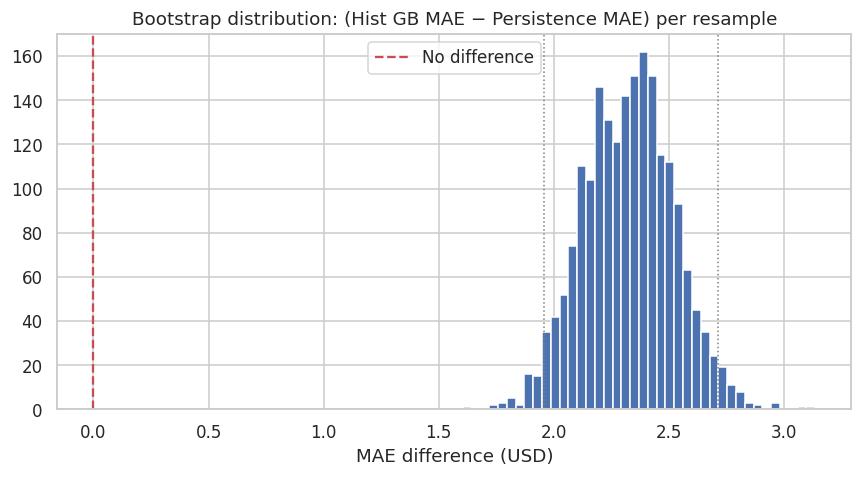

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(diffs, bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(0, color='#C44E52', linestyle='--', linewidth=1.5, label='No difference')
ax.axvline(ci_low, color='gray', linestyle=':', linewidth=1)
ax.axvline(ci_high, color='gray', linestyle=':', linewidth=1)
ax.set_title('Bootstrap distribution: (Hist GB MAE − Persistence MAE) per resample')
ax.set_xlabel('MAE difference (USD)')
ax.legend()
plt.tight_layout()
plt.show()


This confirms §9.8's diagnosis wasn't a fluke of one particular test split: persistence's advantage on
this heterogeneous, multi-scale panel is statistically robust, not sampling noise. This is a genuinely
informative negative result — it tells `13 FINAL MODELS` *not* to ship the panel ML regressor as-is, and to
address the scale-heterogeneity problem identified in `09` (e.g. per-unit-type models or a log/normalized
price target) before it can be expected to beat the simple benchmark.


## 11.3 Classification models (spike risk) — recomputed from saved test predictions

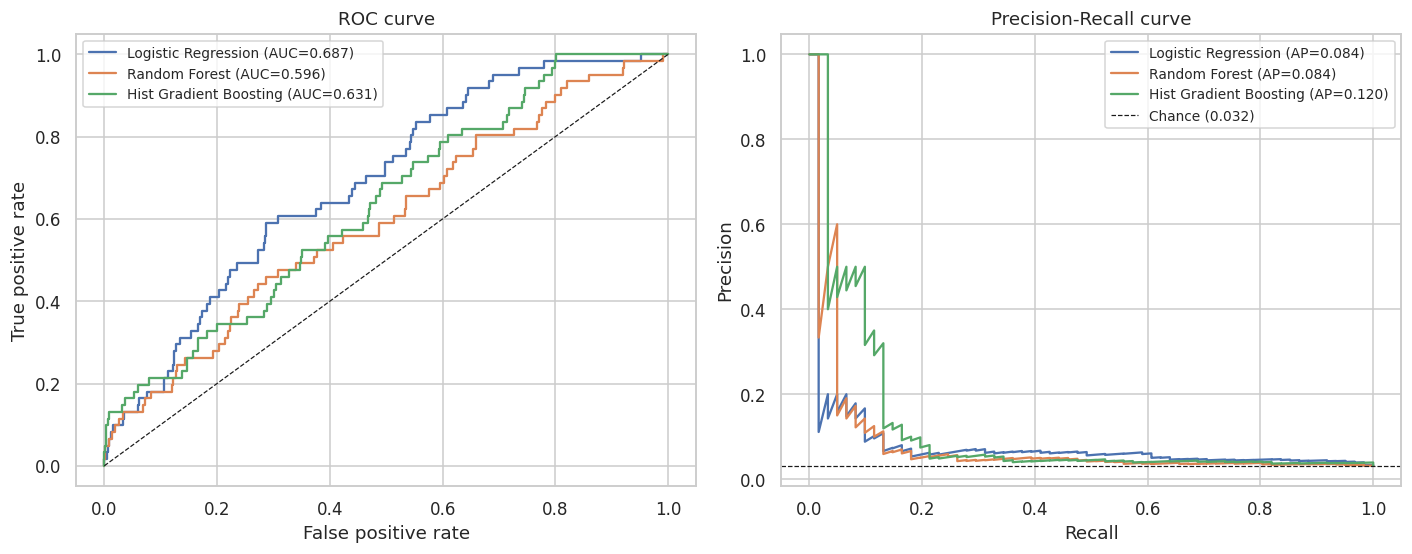

In [6]:
clf_preds = pd.read_csv('../data/10_classification_test_predictions_cereals.csv')
y_test = clf_preds['target_next_is_spike'].astype(int)

clf_models = {
    'Logistic Regression': clf_preds['proba_logistic'],
    'Random Forest': clf_preds['proba_random_forest'],
    'Hist Gradient Boosting': clf_preds['proba_hist_gb'],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for name, proba in clf_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate'); axes[0].set_title('ROC curve')
axes[0].legend(fontsize=9)

base_rate = y_test.mean()
axes[1].axhline(base_rate, color='k', linestyle='--', linewidth=0.8, label=f'Chance ({base_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall curve')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


## 11.4 A more actionable metric: precision in the top-k% highest-risk predictions

In [7]:
def precision_at_k_pct(y_true, proba, k_pct):
    n = len(y_true)
    k = max(1, int(n * k_pct / 100))
    top_idx = np.argsort(-proba)[:k]
    return y_true.values[top_idx].mean()

k_grid = [1, 2, 5, 10, 20]
topk_table = pd.DataFrame({
    name: [precision_at_k_pct(y_test, proba.values, k) for k in k_grid]
    for name, proba in clf_models.items()
}, index=[f'Top {k}%' for k in k_grid])
topk_table['Base rate'] = base_rate
topk_table


,Logistic Regression,Random Forest,Hist Gradient Boosting,Base rate
Top 1%,0.157895,0.157895,0.315789,0.031672
Top 2%,0.157895,0.131579,0.210526,0.031672
Top 5%,0.083333,0.083333,0.104167,0.031672
Top 10%,0.057292,0.057292,0.067708,0.031672
Top 20%,0.064935,0.044156,0.051948,0.031672


If this model were used operationally — e.g. "review the top 5% highest-risk market/commodity series
each month" — this table is the metric that actually matters: how much better than the base rate (shown in
the table's last column) is precision within that reviewed shortlist? A large lift here is meaningful even
when overall PR-AUC looks modest, because an analyst never reviews *all* series, only the flagged ones.


## 11.5 Final recommendation

In [8]:
recommendation = pd.DataFrame([
    {'Task': 'Single-series national forecasting', 'Winner': 'Drift', 'Why': 'Lowest RMSE; simple, transparent, trend-aware'},
    {'Task': 'Panel-level next-month price (regression)', 'Winner': 'Persistence (with caveat)',
     'Why': 'Beats all tested ML models with a statistically robust margin; ML needs scale-heterogeneity fix (see 9.8) before reconsideration'},
    {'Task': 'Next-month spike risk (classification)', 'Winner': 'Hist Gradient Boosting',
     'Why': 'Best PR-AUC and top-k precision under class imbalance; native categorical handling'},
])
recommendation


,Task,Winner,Why
0,Single-series national forecasting,Drift,"Lowest RMSE; simple, transparent, trend-aware"
1,Panel-level next-month price (regression),Persistence (with caveat),Beats all tested ML models with a statisticall...
2,Next-month spike risk (classification),Hist Gradient Boosting,Best PR-AUC and top-k precision under class im...


These three recommendations set the agenda for the rest of the project:

- **`12 EXPLAINABILITY`** focuses on the Hist Gradient Boosting spike classifier (the one clear ML win) and
  the panel regressor (to understand *why* it currently loses to persistence, which is itself explanatory
  work worth doing).
- **`13 FINAL MODELS`** ships the Drift method for single-series forecasting, the persistence benchmark
  (or an improved, scale-aware ML model if time allows) for panel-level price forecasting, and the Hist
  Gradient Boosting classifier for spike early-warning.
